## GeoAI Ghent 2026
This notebook contains the data processing and analysis of a number of LLM generated synthetic spatial datasets. 

In [ ]:
import pandas as pd
import geopandas as gpd
import os
import matplotlib.pyplot as plt
import contextily as cx
cwd = os.getcwd() + "/llm-outputs/"
if not os.path.exists(os.getcwd() + "/plots/"):
    os.mkdir(os.getcwd() + "/plots/")
model_keywords = ["claude", "gemini", "gpt4", "gpt5.4" "gpt-oss-20b", "gpt-oss-120b", "llama", "radian"]
locations = ["london", "berlin"]
tasks = ["A", "B", "C"]

## Task A - Synthetic Data

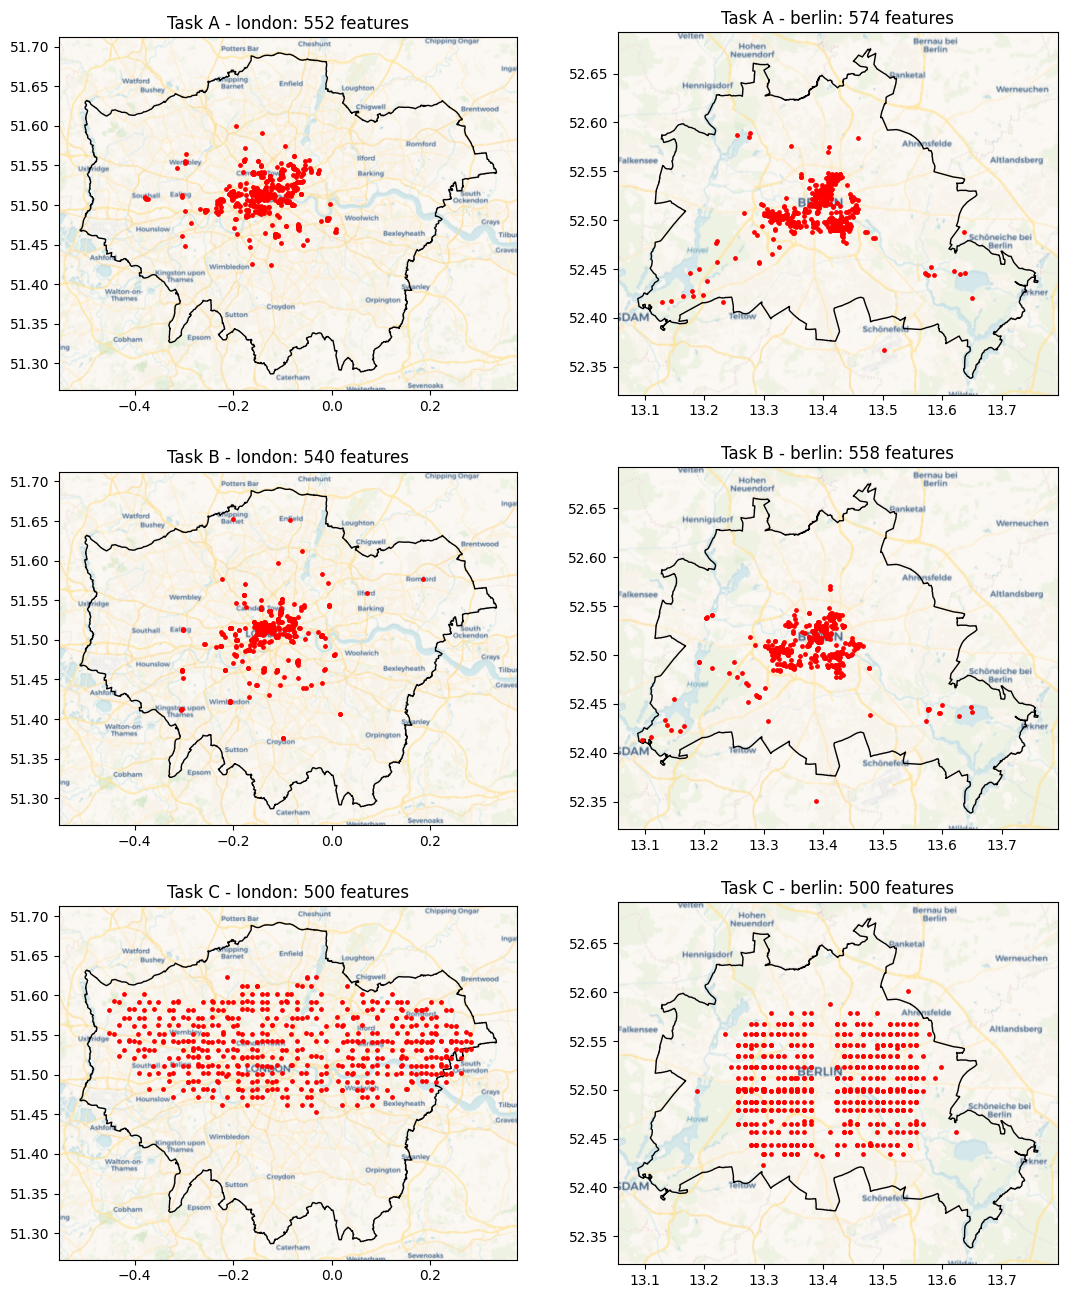

In [31]:

for model in ["claude"]:
    fig, axs = plt.subplots(3,2, figsize=(13,16))
    #fig.suptitle(f"{model}")
    for i, task in enumerate(tasks):
        for j, loc in enumerate(locations):
            bounds = gpd.read_file(f"{loc}_4326.geojson")
            gdf = gpd.read_file(f"{cwd}{model}/validated/task{task}_{loc}_{model}.geojson")
            axs[i][j].set_title(f"Task {task} - {loc}: {len(gdf)} features")
            bounds.plot(ax=axs[i][j], edgecolor='black', facecolor='none')
            cx.add_basemap(ax=axs[i][j], crs='EPSG:4326', attribution=False, source=cx.providers.CartoDB.Voyager)
            if len(gdf) > 0:
                gdf.plot(ax=axs[i][j], color='red', markersize=6)
    #plt.savefig(f"plots/{model}_taskABC_{loc}.png")


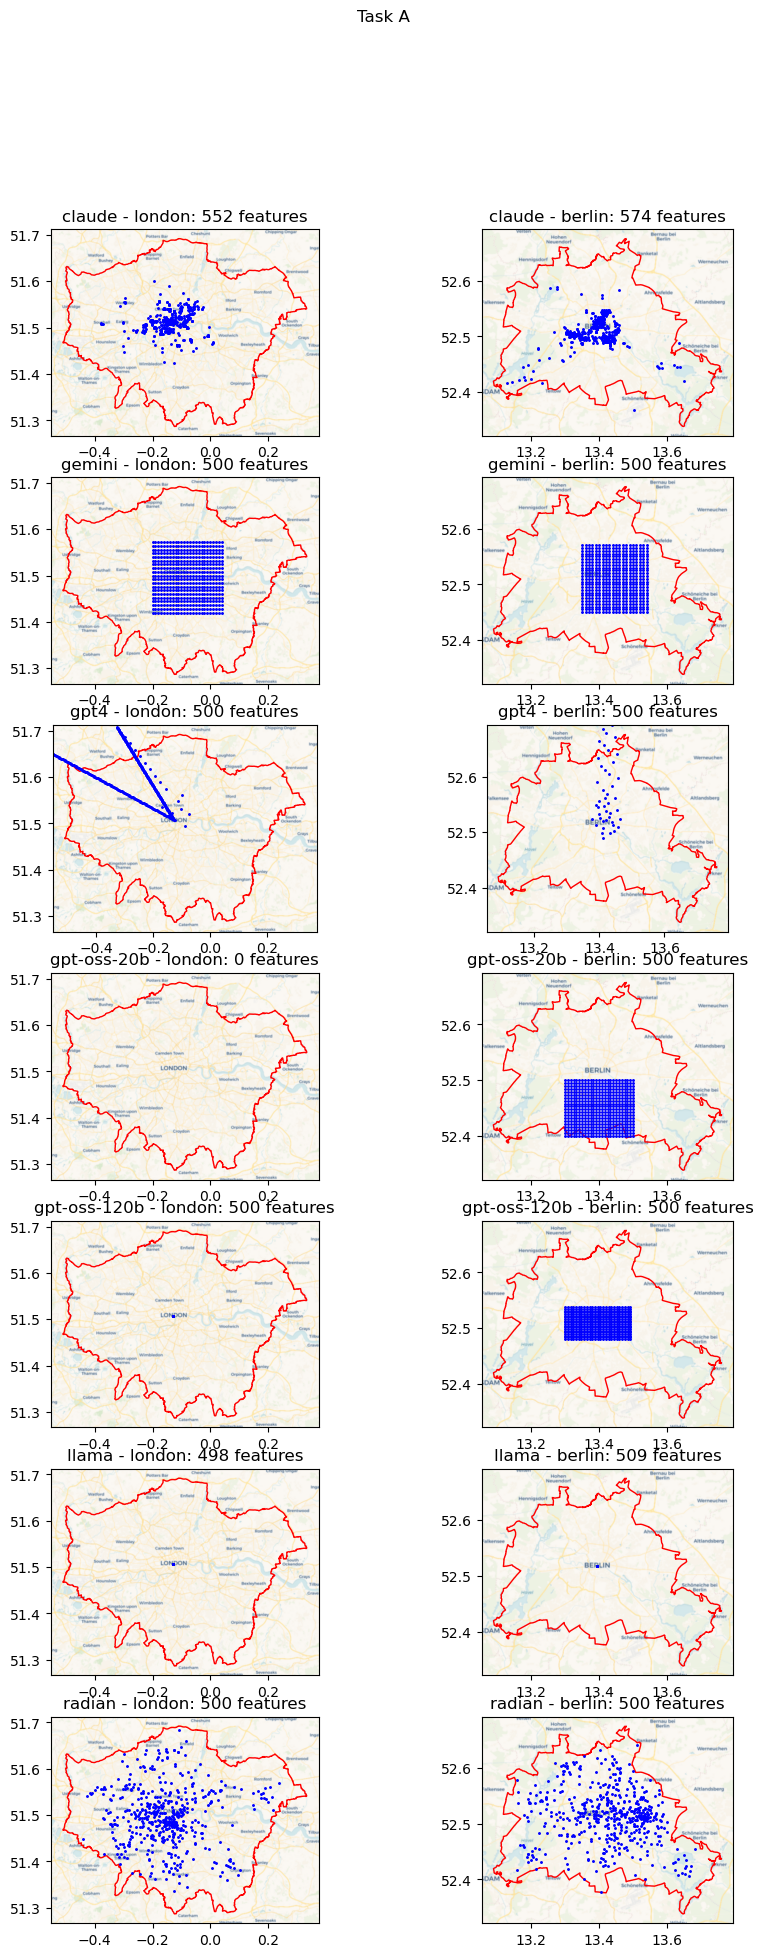

In [24]:

for task in ["A"]:
    fig, axs = plt.subplots(7,2, figsize=(10,22))
    fig.suptitle(f"Task {task}")
    i = 0
    for model in model_keywords:
        for loc in locations:
            bounds = gpd.read_file(f"{loc}_4326.geojson")
            gdf = gpd.read_file(f"{cwd}{model}/validated/task{task}_{loc}_{model}.geojson")
            axs.flatten()[i].set_title(f"{model} - {loc}: {len(gdf)} features")
            bounds.plot(ax=axs.flatten()[i], edgecolor='red', facecolor='none')
            cx.add_basemap(ax=axs.flatten()[i], crs='EPSG:4326', attribution=False, source=cx.providers.CartoDB.Voyager)
            if len(gdf) > 0:
                gdf.plot(ax=axs.flatten()[i], color='blue', markersize=1.2)
            i += 1